In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

LR_SIZE = 128
HR_SIZE = 256
CHANNELS = 1
CHECKPOINT_PATH = Path("train/medr_net_best.h5")
NOISYLR_DIR = Path(r"NoisyLR")


OUTPUT_DIR = Path(r"Restoration_Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
input_files = sorted(NOISYLR_DIR.glob("*.npy"))

print(f"Found {len(input_files)} input images.")

Found 400 input images.


In [5]:
def degradation_aware_extraction(x, filters=64, name="dafe"):
    feat = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv1")(x)
    feat = layers.LeakyReLU(0.2, name=f"{name}_act1")(feat)

    gate = layers.GlobalAveragePooling2D(name=f"{name}_gap")(feat)
    gate = layers.Dense(filters // 4, activation="relu", name=f"{name}_fc1")(gate)
    gate = layers.Dense(filters, activation="sigmoid", name=f"{name}_fc2")(gate)
    gate = layers.Reshape((1, 1, filters), name=f"{name}_reshape")(gate)

    feat = layers.Multiply(name=f"{name}_gate_mul")([feat, gate])
    feat = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv2")(feat)
    feat = layers.LeakyReLU(0.2, name=f"{name}_act2")(feat)
    return feat


def multi_scale_residual_block(x, filters=64, block_id=0):
    name = f"msrl_{block_id}"
    branch1 = layers.Conv2D(filters, 3, padding="same", dilation_rate=1, name=f"{name}_b1")(x)
    branch2 = layers.Conv2D(filters, 3, padding="same", dilation_rate=2, name=f"{name}_b2")(x)
    branch3 = layers.Conv2D(filters, 3, padding="same", dilation_rate=4, name=f"{name}_b3")(x)

    fused = layers.Concatenate(name=f"{name}_concat")([branch1, branch2, branch3])
    fused = layers.Conv2D(filters, 1, padding="same", name=f"{name}_fuse")(fused)
    fused = layers.LeakyReLU(0.2, name=f"{name}_act")(fused)

    out = layers.Add(name=f"{name}_residual")([x, fused])
    return out


def multi_scale_residual_learning(x, filters=64, num_blocks=6):
    for i in range(num_blocks):
        x = multi_scale_residual_block(x, filters=filters, block_id=i)
    return x


def sobel_edge_map(x):
    edges = tf.image.sobel_edges(x)
    edges = tf.sqrt(tf.reduce_sum(tf.square(edges), axis=-1) + 1e-8)
    return edges


def edge_aware_enhancement(x, filters=64, name="ease"):
    edge_map = layers.Lambda(sobel_edge_map, name=f"{name}_sobel")(x)
    edge_feat = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv1")(edge_map)
    edge_feat = layers.LeakyReLU(0.2, name=f"{name}_act1")(edge_feat)

    attention = layers.Conv2D(filters, 1, padding="same", activation="sigmoid", name=f"{name}_attn")(edge_feat)
    enhanced = layers.Multiply(name=f"{name}_apply")([x, attention])
    enhanced = layers.Add(name=f"{name}_residual")([x, enhanced])
    return enhanced, edge_feat


def learned_super_resolution(x, filters=64, scale=2, name="lsrr"):
    x = layers.Conv2D(filters * (scale ** 2), 3, padding="same", name=f"{name}_pre_conv")(x)
    x = layers.Lambda(
        lambda t: tf.nn.depth_to_space(t, scale), name=f"{name}_pixel_shuffle"
    )(x)
    x = layers.Conv2D(filters, 3, padding="same", name=f"{name}_post_conv")(x)
    x = layers.LeakyReLU(0.2, name=f"{name}_act")(x)
    return x


def adaptive_feature_fusion(denoised, structural, high_freq, filters=64, name="aff"):
    concat = layers.Concatenate(name=f"{name}_concat")([denoised, structural, high_freq])
    weights = layers.Conv2D(3, 1, padding="same", activation="softmax", name=f"{name}_weights")(concat)

    w0 = layers.Lambda(lambda t: t[..., 0:1], name=f"{name}_w0")(weights)
    w1 = layers.Lambda(lambda t: t[..., 1:2], name=f"{name}_w1")(weights)
    w2 = layers.Lambda(lambda t: t[..., 2:3], name=f"{name}_w2")(weights)

    fused = layers.Add(name=f"{name}_fuse")([
        layers.Multiply()([denoised, w0]),
        layers.Multiply()([structural, w1]),
        layers.Multiply()([high_freq, w2]),
    ])
    fused = layers.Conv2D(filters, 3, padding="same", name=f"{name}_conv")(fused)
    fused = layers.LeakyReLU(0.2, name=f"{name}_act")(fused)
    return fused


def build_medr_net(lr_size=LR_SIZE, channels=CHANNELS, filters=64):
    inputs = layers.Input(shape=(lr_size, lr_size, channels), name="lr_input")

    dafe_feat = degradation_aware_extraction(inputs, filters=filters)
    denoised_feat = multi_scale_residual_learning(dafe_feat, filters=filters, num_blocks=6)
    structural_feat, edge_feat = edge_aware_enhancement(denoised_feat, filters=filters)

    upsampled_denoised = learned_super_resolution(denoised_feat, filters=filters, scale=2, name="lsrr_denoised")
    upsampled_structural = learned_super_resolution(structural_feat, filters=filters, scale=2, name="lsrr_structural")
    upsampled_edge = learned_super_resolution(edge_feat, filters=filters, scale=2, name="lsrr_edge")

    fused = adaptive_feature_fusion(upsampled_denoised, upsampled_structural, upsampled_edge, filters=filters)

    fused = layers.Conv2D(filters, 3, padding="same", name="refine_conv1")(fused)
    fused = layers.LeakyReLU(0.2, name="refine_act1")(fused)
    fused = layers.Conv2D(filters // 2, 3, padding="same", name="refine_conv2")(fused)
    fused = layers.LeakyReLU(0.2, name="refine_act2")(fused)

    output = layers.Conv2D(channels, 3, padding="same", activation="sigmoid", name="restored_output")(fused)

    return Model(inputs=inputs, outputs=output, name="MEDR_Net")


def load_input_array(path):
    path = Path(path)
    if path.suffix.lower() == ".npy":
        img = np.load(path).astype(np.float32)
    else:
        pil_img = Image.open(path)
        pil_img = pil_img.convert("L") if CHANNELS == 1 else pil_img.convert("RGB")
        img = np.array(pil_img).astype(np.float32)
    return img


def normalize(img):
    img = img.astype(np.float32)
    min_val, max_val = img.min(), img.max()
    if max_val > min_val:
        img = (img - min_val) / (max_val - min_val)
    else:
        img = np.zeros_like(img)
    return np.clip(img, 0, 1)


def prepare_model_input(img):
    img = normalize(img)
    if img.ndim == 2:
        img = img[..., np.newaxis]
    if img.shape[0] != LR_SIZE or img.shape[1] != LR_SIZE:
        img_tensor = tf.convert_to_tensor(img[np.newaxis, ...])
        img_tensor = tf.image.resize(img_tensor, [LR_SIZE, LR_SIZE], method="bicubic")
        img = img_tensor.numpy()[0]
    return img[np.newaxis, ...]  # add batch dim


print(f"Rebuilding MEDR-Net architecture and loading weights from:\n  {CHECKPOINT_PATH}")
medr_net = build_medr_net()
medr_net.load_weights(CHECKPOINT_PATH)
print("Weights loaded successfully.")


Rebuilding MEDR-Net architecture and loading weights from:
  train\medr_net_best.h5

Weights loaded successfully.


In [6]:
medr_net.summary()

Model: "MEDR_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ lr_input (InputLayer)         │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_conv1 (Conv2D)           │ (None, 128, 128, 64)      │             640 │ lr_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_act1 (LeakyReLU)         │ (None, 128, 128, 64)      │               0 │ dafe_conv1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_gap                      │ (None, 64)                │               0 │ dafe_act1[0][0]            │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_fc1 (Dense)              │ (None, 16)                │           1,040 │ dafe_gap[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_fc2 (Dense)              │ (None, 64)                │           1,088 │ dafe_fc1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_reshape (Reshape)        │ (None, 1, 1, 64)          │               0 │ dafe_fc2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_gate_mul (Multiply)      │ (None, 128, 128, 64)      │               0 │ dafe_act1[0][0],           │
│                               │                           │                 │ dafe_reshape[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_conv2 (Conv2D)           │ (None, 128, 128, 64)      │          36,928 │ dafe_gate_mul[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dafe_act2 (LeakyReLU)         │ (None, 128, 128, 64)      │               0 │ dafe_conv2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_b1 (Conv2D)            │ (None, 128, 128, 64)      │          36,928 │ dafe_act2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_b2 (Conv2D)            │ (None, 128, 128, 64)      │          36,928 │ dafe_act2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_b3 (Conv2D)            │ (None, 128, 128, 64)      │          36,928 │ dafe_act2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_concat (Concatenate)   │ (None, 128, 128, 192)     │               0 │ msrl_0_b1[0][0],           │
│                               │                           │                 │ msrl_0_b2[0][0],           │
│                               │                           │                 │ msrl_0_b3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ msrl_0_fuse (Conv2D)          │ (None, 128, 128, 64)      │          12,352 │ msrl_0_concat[0][0]        │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,466,708 (5.60 MB)

 Trainable params: 1,466,708 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
for idx, input_path in enumerate(input_files, start=1):
    try:
        raw_input = load_input_array(input_path)
        model_input = prepare_model_input(raw_input)

        restored = medr_net.predict(model_input, verbose=0)[0]
        restored = np.clip(restored, 0, 1)

        stem = input_path.stem

        npy_path = OUTPUT_DIR / f"{stem}_restored.npy"
        np.save(npy_path, restored)

        restored_display = restored
        if restored_display.shape[-1] == 1:
            restored_display = restored_display[..., 0]

        restored_uint8 = (restored_display * 255.0).astype(np.uint8)

        png_path = OUTPUT_DIR / f"{stem}_restored.png"
        Image.fromarray(restored_uint8).save(png_path)

        print(f"[{idx}/{len(input_files)}] {stem} -> saved")

    except Exception as e:
        print(f"[{idx}/{len(input_files)}] {input_path.name} -> ERROR: {e}")

[1/400] 000000 -> saved
[2/400] 000001 -> saved
[3/400] 000002 -> saved
[4/400] 000003 -> saved
[5/400] 000004 -> saved
[6/400] 000005 -> saved
[7/400] 000006 -> saved
[8/400] 000007 -> saved
[9/400] 000008 -> saved
[10/400] 000009 -> saved
[11/400] 000010 -> saved
[12/400] 000011 -> saved
[13/400] 000012 -> saved
[14/400] 000013 -> saved
[15/400] 000014 -> saved
[16/400] 000015 -> saved
[17/400] 000016 -> saved
[18/400] 000017 -> saved
[19/400] 000018 -> saved
[20/400] 000019 -> saved
[21/400] 000020 -> saved
[22/400] 000021 -> saved
[23/400] 000022 -> saved
[24/400] 000023 -> saved
[25/400] 000024 -> saved
[26/400] 000025 -> saved
[27/400] 000026 -> saved
[28/400] 000027 -> saved
[29/400] 000028 -> saved
[30/400] 000029 -> saved
[31/400] 000030 -> saved
[32/400] 000031 -> saved
[33/400] 000032 -> saved
[34/400] 000033 -> saved
[35/400] 000034 -> saved
[36/400] 000035 -> saved
[37/400] 000036 -> saved
[38/400] 000037 -> saved
[39/400] 000038 -> saved
[40/400] 000039 -> saved
[41/400] 

Found 400 matching image pairs.
Displaying 12 image pairs.


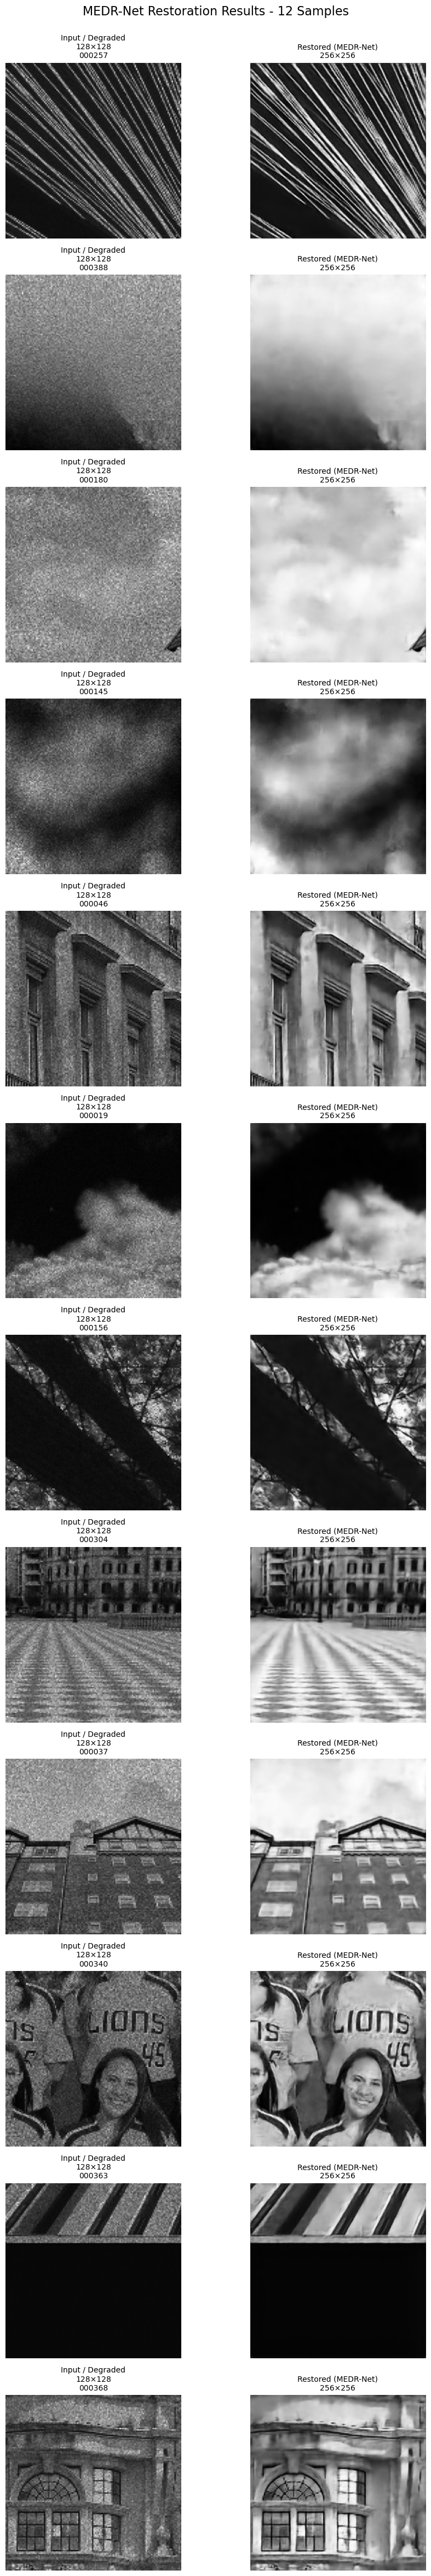


Saved comparison image to:
Restoration_Results\12_sample_restoration_comparison.png


In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
pairs = []
for input_path in input_files:
    stem = input_path.stem
    restored_path = OUTPUT_DIR / f"{stem}_restored.npy"
    if restored_path.exists():
        pairs.append((input_path, restored_path))

print(f"Found {len(pairs)} matching image pairs.")
NUM_SAMPLES=12
if len(pairs) >= NUM_SAMPLES:
    selected_pairs = random.sample(pairs, NUM_SAMPLES)
else:
    selected_pairs = pairs

print(f"Displaying {len(selected_pairs)} image pairs.")

n_samples = len(selected_pairs)
fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4 * n_samples))

if n_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i, (input_path, restored_path) in enumerate(selected_pairs):
    raw_input = load_input_array(input_path)
    model_input = prepare_model_input(raw_input)
    input_display = model_input[0]
    if input_display.shape[-1] == 1:
        input_display = input_display[..., 0]

    restored = np.load(restored_path)
    restored = np.clip(restored, 0, 1)
    restored_display = restored
    if restored_display.shape[-1] == 1:
        restored_display = restored_display[..., 0]

    axes[i, 0].imshow(input_display, cmap="gray" if CHANNELS == 1 else None)
    axes[i, 0].set_title(
        f"Input / Degraded\n"
        f"{input_display.shape[0]}×{input_display.shape[1]}\n"
        f"{input_path.stem}",
        fontsize=10
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(restored_display, cmap="gray" if CHANNELS == 1 else None)
    axes[i, 1].set_title(
        f"Restored (MEDR-Net)\n"
        f"{restored_display.shape[0]}×{restored_display.shape[1]}",
        fontsize=10
    )
    axes[i, 1].axis("off")

fig.suptitle("MEDR-Net Restoration Results - 12 Samples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])

comparison_path = OUTPUT_DIR / "12_sample_restoration_comparison.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"\nSaved comparison image to:\n{comparison_path}")